# 08 — Carteras 2025

**Práctica B3-T4 · Forecasting financiero multivariante (SP500, 23 activos)**

Backtest comparativo de **6 carteras** durante 2025 comparando **3 cerebros** distintos para las predicciones de retorno:

- **TOP_VAL** — el modelo con menor `mae_val` (criterio de selección defendible: sin tocar test).
- **TOP_TEST** — el modelo con menor `mae_test` (mejor número absoluto sobre el split de evaluación).
- **ENSEMBLE** — promedio simple de las 3 redes del deep-dive (`profMIX`, `convLSTM_causal`, `biGRU_attention`) como referencia robusta a la semilla.

Los 3 se eligen **automáticamente** sobre el universo de modelos compatibles con el pipeline de inferencia (input log-returns `(in_w, 23)` → output `(23,)`, `out_window = 90`).

## Diseño experimental

```mermaid
flowchart TD
    A["Selector automatico sobre CSVs de results/"] --> B["3 modelos: top_val, top_test, ensemble"]
    B --> C["Loop sobre rebalances trimestrales 2025"]
    C --> D["X = ultimos in_w dias de log-returns hasta cada rebalance"]
    D --> E["Prediccion: media de retornos a 90 dias por activo"]
    E --> F1["Sin pred: EW, MinVar, MaxSharpe historico"]
    E --> F2["Con pred: Top-K, Momentum tilt, Black-Litterman (x3 modelos)"]
    F1 --> G[Hold portafolio hasta siguiente rebalance]
    F2 --> G
    G --> H[Compute realized returns]
    H --> I["Head-to-head por estrategia + tabla pivote + barchart Sharpe"]
```

## Las 6 carteras

### Sin predicciones (baselines honestos)

| Estrategia | Justificación |
|---|---|
| **EW** equiponderada | Pesos fijos `1/23`. Benchmark neutral. |
| **MinVar** | Minimiza `w' Σ w`; covarianza muestral últimos 252 días. Cap por activo 15%. |
| **Max-Sharpe histórico** | Maximiza Sharpe usando `μ` y `Σ` históricas. |

### Con predicciones (usan el modelo)

| Estrategia | Justificación |
|---|---|
| **Top-K=5 simple** | Top-5 activos por retorno predicho, pesos iguales. |
| **Momentum tilt** | `μ_tilted = μ_hist + λ * pred_return`; maximiza Sharpe con `μ_tilted`. |
| **Black-Litterman** | Prior CAPM (`δ=2.5`) + views Q del modelo. |

## Métricas

Cumulative return, Annualized return, Annualized vol, **Sharpe**, **Max drawdown**, Information ratio vs EW, Tracking error vs EW, Turnover medio.

## Reglas anti-leakage

- Los modelos están entrenados con datos hasta ~2020 (último 10% temporal = test). **2025 es completamente OOS** para todos.
- Para baselines sin predicción (MinVar, MaxSharpe): `μ` y `Σ` calculadas SOLO con los 252 días previos al rebalance (rolling lookback).
- Para baselines con predicción (BL, momentum tilt): mismas `μ`/`Σ` históricas + views del modelo evaluado sobre los últimos `in_w` días hasta la fecha de rebalance.

## Conteo de backtests

- Frecuencia única: **trimestral (Q)**, alineada con el horizonte de predicción `out_window = 90 días ≈ 1 trimestre`.
- 3 baselines sin pred + 1 EW (sin rebalance) + 3 estrategias con-pred × 3 modelos = **13 backtests** (vs los 17 originales mensual+trimestral).


## 1. Setup

In [5]:
import os
import json
import time
import pickle
import random
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

import tensorflow as tf
from tensorflow.keras.models import load_model

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["font.size"] = 9
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3

print(f"TensorFlow {tf.__version__}")


def _resolve_dir(name):
    for cand in [Path(name), Path("..") / name]:
        if cand.exists():
            return cand.resolve()
    p = Path(name)
    p.mkdir(parents=True, exist_ok=True)
    return p.resolve()


RESULTS_DIR = _resolve_dir("results")
MODELS_DIR = _resolve_dir("models")
DATA_DIR = _resolve_dir("data")

N_ASSETS = 23
INPUT_WINDOW = 90
OUTPUT_WINDOW = 90

print(f"RESULTS_DIR : {RESULTS_DIR}")
print(f"MODELS_DIR  : {MODELS_DIR}")
print(f"DATA_DIR    : {DATA_DIR}")

TensorFlow 2.21.0
RESULTS_DIR : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results
MODELS_DIR  : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models
DATA_DIR    : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\data


## 2. Carga de datos, modelos y baseline de competición

Necesitamos:
- **Retornos log** (input al modelo, idéntico al pipeline de competición).
- **Retornos simples** (para calcular retornos realizados de la cartera; convertimos al final).
- **Precios** (para construir series de NAV de cada cartera).
- **Modelo top-1** `mixto_profMIX_in90_out90.keras`.
- **3 modelos del ensemble**: `mixto_dd_{convLSTM_causal, biGRU_attention, profMIX}_in90_out90.keras`.

In [6]:
CACHE_RETURNS = DATA_DIR / "sp500_returns.parquet"
CACHE_PRICES = DATA_DIR / "sp500_close.parquet"

TICKERS = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED", "GD", "GE",
    "HON", "HPQ", "IBM", "IP", "JNJ", "KO", "KR", "MMM", "MO", "MRK",
    "MSI", "PG", "XOM",
]


def _read(p):
    try:
        return pd.read_parquet(p)
    except Exception:
        with open(p.with_suffix(".pkl"), "rb") as f:
            return pickle.load(f)


if not (CACHE_RETURNS.exists() or CACHE_RETURNS.with_suffix(".pkl").exists()):
    raise FileNotFoundError(
        f"No existe el cache de retornos en {CACHE_RETURNS}. "
        "Ejecuta primero 06_mixtos.ipynb o 07_investigacion.ipynb."
    )

returns_df = _read(CACHE_RETURNS if CACHE_RETURNS.exists() else CACHE_RETURNS.with_suffix(".pkl"))
prices_df = _read(CACHE_PRICES if CACHE_PRICES.exists() else CACHE_PRICES.with_suffix(".pkl"))

common_idx = returns_df.index.intersection(prices_df.index)
returns_df = returns_df.loc[common_idx]
prices_df = prices_df.loc[common_idx]
simple_returns_df = prices_df.pct_change().dropna()

print(f"returns_df (log) : {returns_df.shape}  {returns_df.index.min().date()} -> {returns_df.index.max().date()}")
print(f"prices_df        : {prices_df.shape}")
print(f"simple_returns   : {simple_returns_df.shape}")
print(f"Activos          : {list(returns_df.columns)}")

returns_df (log) : (16200, 23)  1962-01-03 -> 2026-05-15
prices_df        : (16200, 23)
simple_returns   : (16199, 23)
Activos          : ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


In [7]:
OUT_WINDOW_TARGET = 90

INV_TECNICAS_COMPATIBLES = {
    "baseline",
    "A2_temporal_split",
    "A4_dbscan_filter",
    "C3_sample_weights",
}

INV_TECNICAS_EXCLUIDAS = {
    "A1_pca_k6", "A1_pca_k10", "A1_pca_k15",
    "B1_simple_returns", "B2_rolling_norm",
    "B3_ewma_vol_channel", "B4_momentum_channel",
    "C1_fracdiff_d0.2", "C1_fracdiff_d0.4", "C1_fracdiff_d0.6",
    "C2_purged_kfold",
    "C4_triple_barrier",
}


def _safe_load(path):
    if not Path(path).exists():
        return None
    try:
        return load_model(path, compile=False)
    except Exception as exc:
        print(f"  ERROR cargando {path}: {type(exc).__name__}: {exc}")
        return None


def _scan_mixtos_csv(csv_path):
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    df = df[df["output_window"] == OUT_WINDOW_TARGET].copy()
    df["familia"] = "mixto"
    df["tecnica"] = df["variante"]
    df["model_file"] = df["model_name"].astype(str) + ".keras"
    return df[["familia", "tecnica", "variante", "input_window", "output_window",
               "mae_val", "mae_test", "model_file"]]


def _scan_deepdive_csv(csv_path):
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    df["familia"] = "mixto_dd"
    df["tecnica"] = "deep_dive"
    df["input_window"] = 90
    df["output_window"] = 90
    df["model_file"] = "mixto_dd_" + df["variante"].astype(str) + "_in90_out90.keras"
    return df[["familia", "tecnica", "variante", "input_window", "output_window",
               "mae_val", "mae_test", "model_file"]]


def _scan_investigacion_csv(csv_path):
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    df = df[df["output_window"] == OUT_WINDOW_TARGET].copy()
    df = df[df["tecnica"].isin(INV_TECNICAS_COMPATIBLES)].copy()
    df = df[df["n_in_channels"] == 23].copy()
    df = df.dropna(subset=["mae_val", "mae_test"])
    df["familia"] = "investigacion"
    df["model_file"] = (
        "inv_" + df["tecnica"].astype(str) + "_" + df["variante"].astype(str)
        + "_in" + df["input_window"].astype(int).astype(str)
        + "_out" + df["output_window"].astype(int).astype(str) + ".keras"
    )
    return df[["familia", "tecnica", "variante", "input_window", "output_window",
               "mae_val", "mae_test", "model_file"]]


df_mix = _scan_mixtos_csv(RESULTS_DIR / "mixtos_resultados.csv")
df_dd = _scan_deepdive_csv(RESULTS_DIR / "mixto_deepdive_finals.csv")
df_inv = _scan_investigacion_csv(RESULTS_DIR / "investigacion_resultados.csv")
df_candidatos = pd.concat([df_mix, df_dd, df_inv], ignore_index=True)

df_candidatos["model_path"] = df_candidatos["model_file"].apply(lambda f: MODELS_DIR / f)
df_candidatos["exists"] = df_candidatos["model_path"].apply(lambda p: p.exists())
df_candidatos = df_candidatos[df_candidatos["exists"]].copy()
df_candidatos = df_candidatos.sort_values(["mae_val", "mae_test"]).reset_index(drop=True)

print(f"Candidatos compatibles con pipeline actual (out_window={OUT_WINDOW_TARGET}, input 23 canales, .keras en disco): {len(df_candidatos)}")
print()

top_val_row = df_candidatos.loc[df_candidatos["mae_val"].idxmin()]
top_test_row = df_candidatos.loc[df_candidatos["mae_test"].idxmin()]

print("TOP 5 por mae_val:")
print(df_candidatos.nsmallest(5, "mae_val")[
    ["familia", "tecnica", "variante", "input_window", "mae_val", "mae_test", "model_file"]
].to_string(index=False))
print()
print("TOP 5 por mae_test:")
print(df_candidatos.nsmallest(5, "mae_test")[
    ["familia", "tecnica", "variante", "input_window", "mae_val", "mae_test", "model_file"]
].to_string(index=False))
print()

TOP_VAL_META = {
    "label": "top_val",
    "model_file": top_val_row["model_file"],
    "input_window": int(top_val_row["input_window"]),
    "mae_val": float(top_val_row["mae_val"]),
    "mae_test": float(top_val_row["mae_test"]),
    "descripcion": f"{top_val_row['familia']}/{top_val_row['tecnica']}/{top_val_row['variante']} in={int(top_val_row['input_window'])}",
}

TOP_TEST_META = {
    "label": "top_test",
    "model_file": top_test_row["model_file"],
    "input_window": int(top_test_row["input_window"]),
    "mae_val": float(top_test_row["mae_val"]),
    "mae_test": float(top_test_row["mae_test"]),
    "descripcion": f"{top_test_row['familia']}/{top_test_row['tecnica']}/{top_test_row['variante']} in={int(top_test_row['input_window'])}",
}

ENSEMBLE_PATHS = {
    "profMIX": MODELS_DIR / "mixto_dd_profMIX_in90_out90.keras",
    "convLSTM_causal": MODELS_DIR / "mixto_dd_convLSTM_causal_in90_out90.keras",
    "biGRU_attention": MODELS_DIR / "mixto_dd_biGRU_attention_in90_out90.keras",
}

print("=" * 80)
print("SELECCION AUTOMATICA")
print("=" * 80)
print(f"  TOP_VAL  : {TOP_VAL_META['model_file']}")
print(f"             {TOP_VAL_META['descripcion']}")
print(f"             mae_val={TOP_VAL_META['mae_val']:.6f}  mae_test={TOP_VAL_META['mae_test']:.6f}")
print(f"  TOP_TEST : {TOP_TEST_META['model_file']}")
print(f"             {TOP_TEST_META['descripcion']}")
print(f"             mae_val={TOP_TEST_META['mae_val']:.6f}  mae_test={TOP_TEST_META['mae_test']:.6f}")
print(f"  ENSEMBLE : promedio simple de {list(ENSEMBLE_PATHS.keys())} (deep-dive in=90 out=90)")
print()

model_top_val = _safe_load(MODELS_DIR / TOP_VAL_META["model_file"])
model_top_test = _safe_load(MODELS_DIR / TOP_TEST_META["model_file"])
print(f"Modelo TOP_VAL  cargado: {'OK' if model_top_val else 'FAIL'}    input_shape={model_top_val.input_shape if model_top_val else 'N/A'}")
print(f"Modelo TOP_TEST cargado: {'OK' if model_top_test else 'FAIL'}    input_shape={model_top_test.input_shape if model_top_test else 'N/A'}")

ensemble_models = {}
for name, path in ENSEMBLE_PATHS.items():
    m = _safe_load(path)
    if m is not None:
        ensemble_models[name] = m
        print(f"Ensemble {name:20s} cargado OK   input_shape={m.input_shape}  params={m.count_params():,}")

print(f"\nResumen: top_val={'OK' if model_top_val else 'FAIL'} | top_test={'OK' if model_top_test else 'FAIL'} | ensemble={len(ensemble_models)}/3")

Candidatos compatibles con pipeline actual (out_window=90, input 23 canales, .keras en disco): 4

TOP 5 por mae_val:
      familia           tecnica        variante  input_window  mae_val  mae_test                                             model_file
investigacion A2_temporal_split         profMIX            90 0.000906  0.001270         inv_A2_temporal_split_profMIX_in90_out90.keras
investigacion A2_temporal_split         profMIX            30 0.000906  0.001267         inv_A2_temporal_split_profMIX_in30_out90.keras
investigacion A2_temporal_split convLSTM_causal            90 0.000916  0.001274 inv_A2_temporal_split_convLSTM_causal_in90_out90.keras
investigacion A2_temporal_split convLSTM_causal            30 0.000918  0.001267 inv_A2_temporal_split_convLSTM_causal_in30_out90.keras

TOP 5 por mae_test:
      familia           tecnica        variante  input_window  mae_val  mae_test                                             model_file
investigacion A2_temporal_split         profMI

In [8]:
YEAR_BACKTEST = 2025

dates_2025 = returns_df.index[returns_df.index.year == YEAR_BACKTEST]
print(f"Dias de trading en {YEAR_BACKTEST}: {len(dates_2025)}")
print(f"  Primer dia: {dates_2025.min().date() if len(dates_2025) > 0 else 'N/A'}")
print(f"  Ultimo dia: {dates_2025.max().date() if len(dates_2025) > 0 else 'N/A'}")

cutoff_start_2024 = pd.Timestamp(f"{YEAR_BACKTEST - 1}-01-01")
hist_for_warmup = returns_df.loc[:dates_2025.min()].tail(252) if len(dates_2025) > 0 else returns_df.tail(252)
print(f"\nDatos historicos previos disponibles para warmup: {len(hist_for_warmup)} dias")
print(f"  desde: {hist_for_warmup.index.min().date()} hasta: {hist_for_warmup.index.max().date()}")

if len(dates_2025) < 100:
    print("\nAVISO: pocos dias de trading en 2025. Esto puede afectar la fiabilidad de las metricas.")

Dias de trading en 2025: 250
  Primer dia: 2025-01-02
  Ultimo dia: 2025-12-31

Datos historicos previos disponibles para warmup: 252 dias
  desde: 2024-01-03 hasta: 2025-01-02


### Reconstrucción adaptativa de los `StandardScaler` usados en entrenamiento

Cada modelo (TOP_VAL, TOP_TEST y los 3 del ensemble) espera inputs y outputs **normalizados** con un `StandardScaler` ajustado sobre el `X_train` exacto que se usó al entrenarlo (`07_mixtos.ipynb` / `08_investigacion.ipynb`). Como ahora distintos modelos pueden tener distinta `input_window` (in=30 vs in=90), construimos los scalers **bajo demanda** y los cacheamos por `(in_w, out_w)` para reutilizarlos entre modelos compatibles.

In [9]:
from sklearn.model_selection import train_test_split as _tts


def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    arr = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(arr) - input_window_size - output_window_size + 1):
        X.append(arr[i : i + input_window_size])
        y.append(np.mean(arr[i + input_window_size : i + input_window_size + output_window_size], axis=0))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def split_triple(X, y, test_size=0.1, val_size=0.1, random_state=RANDOM_SEED):
    X_train_full, X_test, y_train_full, y_test = _tts(X, y, test_size=test_size, shuffle=False)
    X_train, X_val, y_train, y_val = _tts(X_train_full, y_train_full, test_size=val_size, shuffle=True, random_state=random_state)
    return X_train, X_val, X_test, y_train, y_val, y_test


_SCALER_CACHE = {}


def get_scalers(in_w, out_w=OUTPUT_WINDOW):
    """Devuelve (scaler_X, scaler_y) reconstruidos sobre el X_train que produce `split_triple`
    con la `input_window` y `output_window` dadas. Cacheado por (in_w, out_w)."""
    key = (int(in_w), int(out_w))
    if key in _SCALER_CACHE:
        return _SCALER_CACHE[key]
    X_full, y_full = create_time_series_data(returns_df, in_w, out_w)
    X_tr, _, _, y_tr, _, _ = split_triple(X_full, y_full)
    sx = StandardScaler()
    sy = StandardScaler()
    sx.fit(X_tr.reshape(-1, X_tr.shape[-1]))
    sy.fit(y_tr)
    _SCALER_CACHE[key] = (sx, sy)
    print(f"  scaler reconstruido para (in_w={in_w}, out_w={out_w}): X_train shape={X_tr.shape}, "
          f"sX.mean[:3]={sx.mean_[:3]}, sY.mean[:3]={sy.mean_[:3]}")
    return _SCALER_CACHE[key]


print("Construyendo scalers para todos los modelos seleccionados...")
in_widths_needed = set()
if model_top_val is not None:
    in_widths_needed.add(int(model_top_val.input_shape[1]))
if model_top_test is not None:
    in_widths_needed.add(int(model_top_test.input_shape[1]))
for m in ensemble_models.values():
    in_widths_needed.add(int(m.input_shape[1]))

for iw in sorted(in_widths_needed):
    get_scalers(iw, OUTPUT_WINDOW)

print(f"\nScalers en cache: {sorted(_SCALER_CACHE.keys())}")

Construyendo scalers para todos los modelos seleccionados...
  scaler reconstruido para (in_w=30, out_w=90): X_train shape=(13024, 30, 23), sX.mean[:3]=[0.00030423 0.00051102 0.00037075], sY.mean[:3]=[0.00031524 0.00053639 0.00038829]
  scaler reconstruido para (in_w=90, out_w=90): X_train shape=(12976, 90, 23), sX.mean[:3]=[0.00030298 0.00052878 0.000382  ], sY.mean[:3]=[0.00031247 0.00053059 0.00038744]

Scalers en cache: [(30, 90), (90, 90)]


In [10]:
def _predict_single(model, returns_window, in_w, out_w=OUTPUT_WINDOW):
    """Predict generico: normaliza con el scaler de (in_w, out_w), llama al modelo y desescala."""
    sx, sy = get_scalers(in_w, out_w)
    if returns_window.ndim == 2:
        returns_window = returns_window[np.newaxis, ...]
    X_n = sx.transform(returns_window.reshape(-1, returns_window.shape[-1])).reshape(returns_window.shape).astype(np.float32)
    pred_n = model.predict(X_n, verbose=0)
    return sy.inverse_transform(pred_n)[0]


def predict_returns_top_val(returns_window):
    """Predict del modelo TOP_VAL (mejor mae_val). Espera ventana (in_w, 23) sin normalizar."""
    if model_top_val is None:
        raise RuntimeError("model_top_val no esta cargado.")
    return _predict_single(model_top_val, returns_window, in_w=TOP_VAL_META["input_window"])


predict_returns_top_val.input_window = TOP_VAL_META["input_window"]
predict_returns_top_val.descripcion = TOP_VAL_META["descripcion"]


def predict_returns_top_test(returns_window):
    """Predict del modelo TOP_TEST (mejor mae_test). Espera ventana (in_w, 23) sin normalizar."""
    if model_top_test is None:
        raise RuntimeError("model_top_test no esta cargado.")
    return _predict_single(model_top_test, returns_window, in_w=TOP_TEST_META["input_window"])


predict_returns_top_test.input_window = TOP_TEST_META["input_window"]
predict_returns_top_test.descripcion = TOP_TEST_META["descripcion"]


def predict_returns_ensemble(returns_window):
    """Promedio simple de las predicciones de los 3 modelos del deep-dive (todos in=90)."""
    if not ensemble_models:
        raise RuntimeError("ensemble_models vacio.")
    preds = []
    for m in ensemble_models.values():
        in_w = int(m.input_shape[1])
        preds.append(_predict_single(m, returns_window, in_w=in_w))
    return np.mean(preds, axis=0)


_ENSEMBLE_IN_W = int(next(iter(ensemble_models.values())).input_shape[1]) if ensemble_models else 90
predict_returns_ensemble.input_window = _ENSEMBLE_IN_W
predict_returns_ensemble.descripcion = f"ensemble deep-dive ({len(ensemble_models)} modelos, in={_ENSEMBLE_IN_W})"


if len(dates_2025) > 0:
    first_2025 = dates_2025.min()
    window_idx_end = returns_df.index.get_loc(first_2025)
    print(f"Sanity check de predicciones para {first_2025.date()} (target = retorno medio siguientes 90 dias):\n")
    for label, fn in [("TOP_VAL", predict_returns_top_val if model_top_val else None),
                      ("TOP_TEST", predict_returns_top_test if model_top_test else None),
                      ("ENSEMBLE", predict_returns_ensemble if ensemble_models else None)]:
        if fn is None:
            print(f"  {label:8s}: NO disponible")
            continue
        iw = fn.input_window
        win = returns_df.iloc[window_idx_end - iw : window_idx_end].values
        p = fn(win)
        print(f"  {label:8s} ({fn.descripcion}): shape={p.shape} rango=[{p.min():+.6f}, {p.max():+.6f}] mean={p.mean():+.6f}")

Sanity check de predicciones para 2025-01-02 (target = retorno medio siguientes 90 dias):

  TOP_VAL  (investigacion/A2_temporal_split/profMIX in=90): shape=(23,) rango=[+0.000248, +0.000722] mean=+0.000450
  TOP_TEST (investigacion/A2_temporal_split/profMIX in=30): shape=(23,) rango=[+0.000244, +0.000698] mean=+0.000483
  ENSEMBLE: NO disponible


## 3. Funciones de pesos

Una función por estrategia, todas con la misma firma: `(mu_hist, cov_hist, pred_returns) -> weights`. Eso permite usar el mismo `backtest_strategy` para todas.

Hiperparámetros:
- `MAX_WEIGHT = 0.15` (cap por activo, evita concentración extrema).
- `MIN_WEIGHT = 0.0` (no short, todos los pesos no negativos).
- `LOOKBACK_HIST = 252` días para `μ_hist` y `Σ_hist`.
- `TOP_K = 5` para la cartera top-K.
- `DELTA_BL = 2.5` (aversión al riesgo para CAPM equilibrium en Black-Litterman).
- `TAU_BL = 0.05` (escala de incertidumbre del prior en BL).

In [11]:
MAX_WEIGHT = 0.15
MIN_WEIGHT = 0.0
LOOKBACK_HIST = 252
TOP_K = 5
DELTA_BL = 2.5
TAU_BL = 0.05
TRANSACTION_COST_BPS = 5
RISK_FREE = 0.0


def weights_equal(mu, cov, pred, n_assets=N_ASSETS):
    """EW: pesos uniformes 1/n_assets."""
    return np.ones(n_assets) / n_assets


def _solve_min_var(cov, max_w=MAX_WEIGHT, min_w=MIN_WEIGHT):
    n = cov.shape[0]
    w0 = np.ones(n) / n
    def obj(w):
        return float(w @ cov @ w)
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = [(min_w, max_w)] * n
    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-10})
    if not res.success:
        return w0
    return res.x


def weights_min_var(mu, cov, pred, n_assets=N_ASSETS):
    """Minimiza varianza sujeto a sum(w)=1, 0<=w<=MAX_WEIGHT."""
    return _solve_min_var(cov)


def _solve_max_sharpe(mu, cov, rf=RISK_FREE, max_w=MAX_WEIGHT, min_w=MIN_WEIGHT):
    n = len(mu)
    w0 = np.ones(n) / n
    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ cov @ w)
        if port_vol < 1e-10:
            return 0.0
        return -(port_ret - rf) / port_vol
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = [(min_w, max_w)] * n
    res = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-10})
    if not res.success or np.isnan(res.x).any():
        return w0
    return res.x


def weights_max_sharpe_hist(mu, cov, pred, n_assets=N_ASSETS):
    """Max-Sharpe usando mu/cov historicos."""
    return _solve_max_sharpe(mu, cov)


def weights_top_k(mu, cov, pred, n_assets=N_ASSETS, k=TOP_K):
    """Top-K activos por pred return, pesos iguales."""
    order = np.argsort(pred)[-k:]
    w = np.zeros(n_assets)
    w[order] = 1.0 / k
    return w


def weights_momentum_tilt(mu, cov, pred, n_assets=N_ASSETS):
    """μ_tilted = μ_hist + λ * normalized pred. Max-Sharpe con tilted mu.

    λ = std(mu_hist) — escala las predicciones al rango natural de los retornos historicos.
    """
    pred_norm = (pred - pred.mean()) / (pred.std() + 1e-9)
    lam = mu.std()
    mu_tilted = mu + lam * pred_norm
    return _solve_max_sharpe(mu_tilted, cov)


def weights_black_litterman(mu, cov, pred, n_assets=N_ASSETS, delta=DELTA_BL, tau=TAU_BL):
    """Black-Litterman con views Q = pred.

    Prior: pi = delta * Sigma * w_market (asumimos w_market = equal-weight para simplificar).
    Views: P = identidad (una view por activo), Q = pred returns.
    Omega: diagonal con tau * diag(P @ Sigma @ P.T).
    """
    w_mkt = np.ones(n_assets) / n_assets
    pi = delta * cov @ w_mkt
    P = np.eye(n_assets)
    omega = np.diag(np.diag(tau * (P @ cov @ P.T)) + 1e-8)
    tau_cov = tau * cov
    try:
        tau_cov_inv = np.linalg.inv(tau_cov)
    except np.linalg.LinAlgError:
        return _solve_max_sharpe(mu, cov)
    try:
        omega_inv = np.linalg.inv(omega)
    except np.linalg.LinAlgError:
        return _solve_max_sharpe(mu, cov)
    posterior_cov_inv = tau_cov_inv + P.T @ omega_inv @ P
    try:
        posterior_cov = np.linalg.inv(posterior_cov_inv)
    except np.linalg.LinAlgError:
        return _solve_max_sharpe(mu, cov)
    mu_bl = posterior_cov @ (tau_cov_inv @ pi + P.T @ omega_inv @ pred)
    return _solve_max_sharpe(mu_bl, cov + posterior_cov)


STRATEGIES = {
    "EW": {"fn": weights_equal, "uses_pred": False, "rebalances": False},
    "MinVar": {"fn": weights_min_var, "uses_pred": False, "rebalances": True},
    "MaxSharpe_hist": {"fn": weights_max_sharpe_hist, "uses_pred": False, "rebalances": True},
    "TopK_pred": {"fn": weights_top_k, "uses_pred": True, "rebalances": True},
    "Momentum_tilt_pred": {"fn": weights_momentum_tilt, "uses_pred": True, "rebalances": True},
    "BlackLitterman_pred": {"fn": weights_black_litterman, "uses_pred": True, "rebalances": True},
}

print(f"Estrategias definidas: {list(STRATEGIES.keys())}")

Estrategias definidas: ['EW', 'MinVar', 'MaxSharpe_hist', 'TopK_pred', 'Momentum_tilt_pred', 'BlackLitterman_pred']


## 4. Backtest

- `get_rebalance_dates(year, freq)` — primer día hábil de cada mes (freq='M') o trimestre ('Q').
- `backtest_strategy(weights_fn, freq, predict_fn)` — loop con realized returns + cost de transacción.
- `compute_portfolio_metrics(daily_returns)` — todas las métricas estándar.

In [12]:
def get_rebalance_dates(year, freq, dates_index):
    """Devuelve fechas de rebalance dentro de `year` segun frecuencia M (mensual) o Q (trimestral).

    Para cada periodo, toma el primer dia HABIL disponible en `dates_index`.
    """
    year_dates = dates_index[dates_index.year == year]
    if len(year_dates) == 0:
        return []

    rebalance_dates = []
    if freq == "M":
        for month in range(1, 13):
            mdates = year_dates[year_dates.month == month]
            if len(mdates) > 0:
                rebalance_dates.append(mdates[0])
    elif freq == "Q":
        for q_month in [1, 4, 7, 10]:
            mdates = year_dates[year_dates.month == q_month]
            if len(mdates) > 0:
                rebalance_dates.append(mdates[0])
    elif freq == "Y":
        rebalance_dates.append(year_dates[0])
    return rebalance_dates


def _hist_mu_cov(returns_simple, end_date, lookback=LOOKBACK_HIST):
    """Calcula mu (media diaria) y cov (matriz de covarianza diaria) de los `lookback` dias previos a end_date."""
    idx_end = returns_simple.index.get_loc(end_date)
    start = max(0, idx_end - lookback)
    hist = returns_simple.iloc[start:idx_end]
    return hist.mean().values, hist.cov().values


def _predict_for_date(returns_log, rebalance_date, predict_fn):
    """Construye la ventana previa a `rebalance_date` y llama al `predict_fn`.

    Usa `predict_fn.input_window` si esta definido (cada modelo lleva su propio in_w),
    cae a la constante `INPUT_WINDOW` global como respaldo.
    """
    in_w = int(getattr(predict_fn, "input_window", INPUT_WINDOW))
    idx_end = returns_log.index.get_loc(rebalance_date)
    if idx_end < in_w:
        return None
    window = returns_log.iloc[idx_end - in_w : idx_end].values
    pred_log = predict_fn(window)
    return pred_log


def backtest_strategy(
    *,
    strategy_name,
    freq,
    returns_log,
    returns_simple,
    predict_fn=None,
    year=YEAR_BACKTEST,
    transaction_cost_bps=TRANSACTION_COST_BPS,
):
    """Backtest una estrategia durante `year` con la frecuencia y predict_fn dados.

    Devuelve dict con: weights_history, daily_returns, nav_series, dates_rebalance.
    """
    cfg = STRATEGIES[strategy_name]
    if not cfg["rebalances"]:
        actual_freq = "Y"
    else:
        actual_freq = freq
    rebalance_dates = get_rebalance_dates(year, actual_freq, returns_simple.index)
    if not rebalance_dates:
        return None

    year_dates = returns_simple.index[returns_simple.index.year == year]
    daily_port_rets = pd.Series(index=year_dates, dtype=float)
    weights_history = pd.DataFrame(index=rebalance_dates, columns=returns_simple.columns, dtype=float)
    predictions_history = pd.DataFrame(index=rebalance_dates, columns=returns_simple.columns, dtype=float)
    turnovers = []

    current_weights = None
    last_weights = None

    for i, reb_date in enumerate(rebalance_dates):
        mu_h, cov_h = _hist_mu_cov(returns_simple, reb_date, lookback=LOOKBACK_HIST)

        pred = None
        if cfg["uses_pred"]:
            if predict_fn is None:
                raise ValueError(f"strategy {strategy_name} requires predict_fn")
            pred = _predict_for_date(returns_log, reb_date, predict_fn)
            if pred is None:
                continue
            predictions_history.loc[reb_date] = pred

        try:
            w = cfg["fn"](mu_h, cov_h, pred)
        except Exception as exc:
            print(f"    rebalance {reb_date.date()}: error en pesos ({type(exc).__name__}: {exc}), uso EW")
            w = np.ones(N_ASSETS) / N_ASSETS

        w = np.clip(w, MIN_WEIGHT, MAX_WEIGHT)
        if w.sum() > 0:
            w = w / w.sum()

        weights_history.loc[reb_date] = w

        if last_weights is None:
            turnover = w.sum()
        else:
            turnover = np.abs(w - last_weights).sum() / 2
        turnovers.append(turnover)

        next_reb = rebalance_dates[i + 1] if i + 1 < len(rebalance_dates) else None
        period_dates = year_dates[(year_dates >= reb_date) & ((year_dates < next_reb) if next_reb is not None else (year_dates >= reb_date))]

        for d in period_dates:
            day_rets = returns_simple.loc[d].values
            daily_port_rets.loc[d] = float(np.sum(w * day_rets))

        if turnover > 0:
            daily_port_rets.loc[reb_date] -= turnover * (transaction_cost_bps / 10000)

        last_weights = w
        current_weights = w

    daily_port_rets = daily_port_rets.dropna()
    nav = (1 + daily_port_rets).cumprod()
    weights_history = weights_history.dropna(how="all")

    return {
        "strategy": strategy_name,
        "freq": actual_freq,
        "daily_returns": daily_port_rets,
        "nav": nav,
        "weights_history": weights_history,
        "predictions_history": predictions_history.dropna(how="all"),
        "rebalance_dates": rebalance_dates,
        "turnovers": turnovers,
    }


def compute_portfolio_metrics(daily_returns, benchmark_returns=None):
    """Computa metricas estandar de un backtest."""
    daily_returns = pd.Series(daily_returns).dropna()
    if len(daily_returns) == 0:
        return {}
    cum = (1 + daily_returns).cumprod()
    cum_ret = float(cum.iloc[-1] - 1)
    n = len(daily_returns)
    ann_factor = 252
    ann_ret = float((1 + daily_returns.mean()) ** ann_factor - 1)
    ann_vol = float(daily_returns.std() * np.sqrt(ann_factor))
    sharpe = float((daily_returns.mean() * ann_factor - RISK_FREE) / (ann_vol + 1e-12))
    running_max = cum.cummax()
    drawdown = (cum / running_max) - 1.0
    max_dd = float(drawdown.min())

    metrics = {
        "cum_return": cum_ret,
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "n_days": int(n),
    }
    if benchmark_returns is not None:
        bench = pd.Series(benchmark_returns).reindex(daily_returns.index).dropna()
        common = daily_returns.index.intersection(bench.index)
        if len(common) > 5:
            d_aligned = daily_returns.loc[common]
            b_aligned = bench.loc[common]
            active = d_aligned - b_aligned
            te = float(active.std() * np.sqrt(ann_factor))
            ir = float((active.mean() * ann_factor) / (te + 1e-12))
            metrics["tracking_error"] = te
            metrics["information_ratio"] = ir
    return metrics

print("Backtest functions definidas.")

Backtest functions definidas.


## 5. Loop principal

Frecuencia única **trimestral (`Q`)** — alineada con el horizonte `out_window = 90 días`.

Ejecutamos:
- **EW**: una vez (no se rebalancea) → 1 backtest.
- **MinVar, MaxSharpe_hist**: una vez con freq `Q` (no usan predicción) → 2 backtests.
- **TopK_pred, Momentum_tilt_pred, BlackLitterman_pred**: una vez por modelo (top_val, top_test, ensemble) → 9 backtests.

Total: **12 backtests**. Output guardado en `carteras_2025_resultados.csv`.

In [13]:
REBALANCE_FREQ = "Q"

PRED_MODELS = {}
PRED_META = {}

if model_top_val is not None:
    PRED_MODELS["top_val"] = predict_returns_top_val
    PRED_META["top_val"] = TOP_VAL_META
if model_top_test is not None:
    PRED_MODELS["top_test"] = predict_returns_top_test
    PRED_META["top_test"] = TOP_TEST_META
if ensemble_models:
    PRED_MODELS["ensemble"] = predict_returns_ensemble
    PRED_META["ensemble"] = {
        "label": "ensemble",
        "model_file": "(ensemble deep-dive top-3)",
        "input_window": _ENSEMBLE_IN_W,
        "mae_val": None,
        "mae_test": None,
        "descripcion": predict_returns_ensemble.descripcion,
    }

print(f"Frecuencia de rebalance : {REBALANCE_FREQ} (trimestral)")
print(f"Modelos de prediccion   : {list(PRED_MODELS.keys())}")
for k, meta in PRED_META.items():
    extra = ""
    if meta["mae_val"] is not None:
        extra = f"  mae_val={meta['mae_val']:.6f}  mae_test={meta['mae_test']:.6f}"
    print(f"  {k:9s} -> {meta['descripcion']}{extra}")
print()

bench_returns = simple_returns_df[simple_returns_df.index.year == YEAR_BACKTEST].mean(axis=1)

backtest_runs = []
results_rows = []

t0_global = time.time()

for strat_name, cfg in STRATEGIES.items():
    if not cfg["uses_pred"]:
        if cfg["rebalances"]:
            print(f"Backtest: {strat_name:25s} freq={REBALANCE_FREQ}")
            bt = backtest_strategy(
                strategy_name=strat_name, freq=REBALANCE_FREQ,
                returns_log=returns_df, returns_simple=simple_returns_df,
                predict_fn=None,
            )
            if bt is None:
                continue
            metrics = compute_portfolio_metrics(bt["daily_returns"], benchmark_returns=bench_returns)
            row = {"strategy": strat_name, "freq": REBALANCE_FREQ, "pred_model": "none", **metrics}
            row["mean_turnover"] = float(np.mean(bt["turnovers"])) if bt["turnovers"] else 0.0
            row["n_rebalances"] = len(bt["rebalance_dates"])
            results_rows.append(row)
            backtest_runs.append({"key": f"{strat_name}_predNone", **bt, **metrics})
            print(f"  sharpe={metrics.get('sharpe', 0):+.3f}  ann_ret={metrics.get('ann_return', 0):+.2%}  ann_vol={metrics.get('ann_vol', 0):.2%}  MDD={metrics.get('max_drawdown', 0):+.2%}")
        else:
            print(f"Backtest: {strat_name:25s} freq=Y (no rebalance)")
            bt = backtest_strategy(
                strategy_name=strat_name, freq="Y",
                returns_log=returns_df, returns_simple=simple_returns_df,
                predict_fn=None,
            )
            if bt is not None:
                metrics = compute_portfolio_metrics(bt["daily_returns"], benchmark_returns=bench_returns)
                row = {"strategy": strat_name, "freq": "Y", "pred_model": "none", **metrics}
                row["mean_turnover"] = float(np.mean(bt["turnovers"])) if bt["turnovers"] else 0.0
                row["n_rebalances"] = len(bt["rebalance_dates"])
                results_rows.append(row)
                backtest_runs.append({"key": f"{strat_name}_predNone", **bt, **metrics})
                print(f"  sharpe={metrics.get('sharpe', 0):+.3f}  ann_ret={metrics.get('ann_return', 0):+.2%}  ann_vol={metrics.get('ann_vol', 0):.2%}  MDD={metrics.get('max_drawdown', 0):+.2%}")
    else:
        for pred_name, pred_fn in PRED_MODELS.items():
            print(f"Backtest: {strat_name:25s} freq={REBALANCE_FREQ}  pred={pred_name}")
            bt = backtest_strategy(
                strategy_name=strat_name, freq=REBALANCE_FREQ,
                returns_log=returns_df, returns_simple=simple_returns_df,
                predict_fn=pred_fn,
            )
            if bt is None:
                continue
            metrics = compute_portfolio_metrics(bt["daily_returns"], benchmark_returns=bench_returns)
            row = {"strategy": strat_name, "freq": REBALANCE_FREQ, "pred_model": pred_name, **metrics}
            row["mean_turnover"] = float(np.mean(bt["turnovers"])) if bt["turnovers"] else 0.0
            row["n_rebalances"] = len(bt["rebalance_dates"])
            results_rows.append(row)
            backtest_runs.append({"key": f"{strat_name}_pred{pred_name}", **bt, **metrics})
            print(f"  sharpe={metrics.get('sharpe', 0):+.3f}  ann_ret={metrics.get('ann_return', 0):+.2%}  ann_vol={metrics.get('ann_vol', 0):.2%}  MDD={metrics.get('max_drawdown', 0):+.2%}")

print()
print(f"Total backtests ejecutados: {len(backtest_runs)} en {(time.time()-t0_global)/60:.1f} min")

Frecuencia de rebalance : Q (trimestral)
Modelos de prediccion   : ['top_val', 'top_test']
  top_val   -> investigacion/A2_temporal_split/profMIX in=90  mae_val=0.000906  mae_test=0.001270
  top_test  -> investigacion/A2_temporal_split/profMIX in=30  mae_val=0.000906  mae_test=0.001267

Backtest: EW                        freq=Y (no rebalance)
  sharpe=+1.199  ann_ret=+17.83%  ann_vol=13.69%  MDD=-11.13%
Backtest: MinVar                    freq=Q
  sharpe=+1.075  ann_ret=+15.24%  ann_vol=13.20%  MDD=-10.94%
Backtest: MaxSharpe_hist            freq=Q
  sharpe=+1.383  ann_ret=+20.40%  ann_vol=13.43%  MDD=-9.54%
Backtest: TopK_pred                 freq=Q  pred=top_val
  sharpe=+1.393  ann_ret=+30.41%  ann_vol=19.07%  MDD=-15.07%
Backtest: TopK_pred                 freq=Q  pred=top_test
  sharpe=+1.084  ann_ret=+17.60%  ann_vol=14.96%  MDD=-11.09%
Backtest: Momentum_tilt_pred        freq=Q  pred=top_val
  sharpe=+1.310  ann_ret=+18.97%  ann_vol=13.27%  MDD=-9.48%
Backtest: Momentum_tilt_pr

In [14]:
df_results = pd.DataFrame(results_rows)
if len(df_results) > 0:
    cols_order = ["strategy", "freq", "pred_model", "cum_return", "ann_return", "ann_vol", "sharpe",
                  "max_drawdown", "tracking_error", "information_ratio", "mean_turnover", "n_rebalances", "n_days"]
    cols_existing = [c for c in cols_order if c in df_results.columns]
    df_results = df_results[cols_existing]
    df_results.to_csv(RESULTS_DIR / "carteras_2025_resultados.csv", index=False)
    print(f"Guardado: {RESULTS_DIR / 'carteras_2025_resultados.csv'}")
    print()
    print(df_results.to_string(index=False))

returns_df_export = pd.DataFrame({bt["key"]: bt["daily_returns"] for bt in backtest_runs}).reset_index()
returns_df_export.columns = ["date"] + list(returns_df_export.columns[1:])
returns_df_export.to_csv(RESULTS_DIR / "carteras_2025_returns.csv", index=False)
print(f"\nGuardado: {RESULTS_DIR / 'carteras_2025_returns.csv'}")

weights_rows = []
for bt in backtest_runs:
    if bt["weights_history"] is None or len(bt["weights_history"]) == 0:
        continue
    wh = bt["weights_history"].copy()
    wh["strategy_key"] = bt["key"]
    wh = wh.reset_index().rename(columns={"index": "date"})
    weights_rows.append(wh)
if weights_rows:
    weights_export = pd.concat(weights_rows, ignore_index=True)
    weights_export.to_csv(RESULTS_DIR / "carteras_2025_pesos.csv", index=False)
    print(f"Guardado: {RESULTS_DIR / 'carteras_2025_pesos.csv'}")

Guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\carteras_2025_resultados.csv

           strategy freq pred_model  cum_return  ann_return  ann_vol   sharpe  max_drawdown  tracking_error  information_ratio  mean_turnover  n_rebalances  n_days
                 EW    Y       none    0.165929    0.178320 0.136856 1.199385     -0.111321        0.000502          -1.003992       1.000000             1     250
             MinVar    Q       none    0.141184    0.152374 0.132023 1.074542     -0.109387        0.047735          -0.477271       0.423552             4     250
     MaxSharpe_hist    Q       none    0.191519    0.203977 0.134303 1.382681     -0.095449        0.072853           0.288969       0.517523             4     250
          TopK_pred    Q    top_val    0.278192    0.304058 0.190727 1.392679     -0.150743        0.104418           0.967019       0.600000             4     250
          TopK_pred    Q   top_test    0.161552    0.176014 0.

## 6. Visualización head-to-head

Tres gráficas clave:
1. **Head-to-head por estrategia con-pred** (3 paneles, uno por estrategia): NAV de los 3 modelos (`top_val`, `top_test`, `ensemble`) frente a la baseline sin-pred más cercana (EW para TopK, MaxSharpe histórico para MomTilt y BL), con mini-tabla de métricas debajo.
2. **Tabla pivote estrategia × modelo** con Sharpe / ann_return / MDD: panorama compacto de qué cerebro funciona mejor en cada estrategia.
3. **Barchart agrupado de Sharpe** por estrategia, con línea de referencia del mejor baseline sin pred.

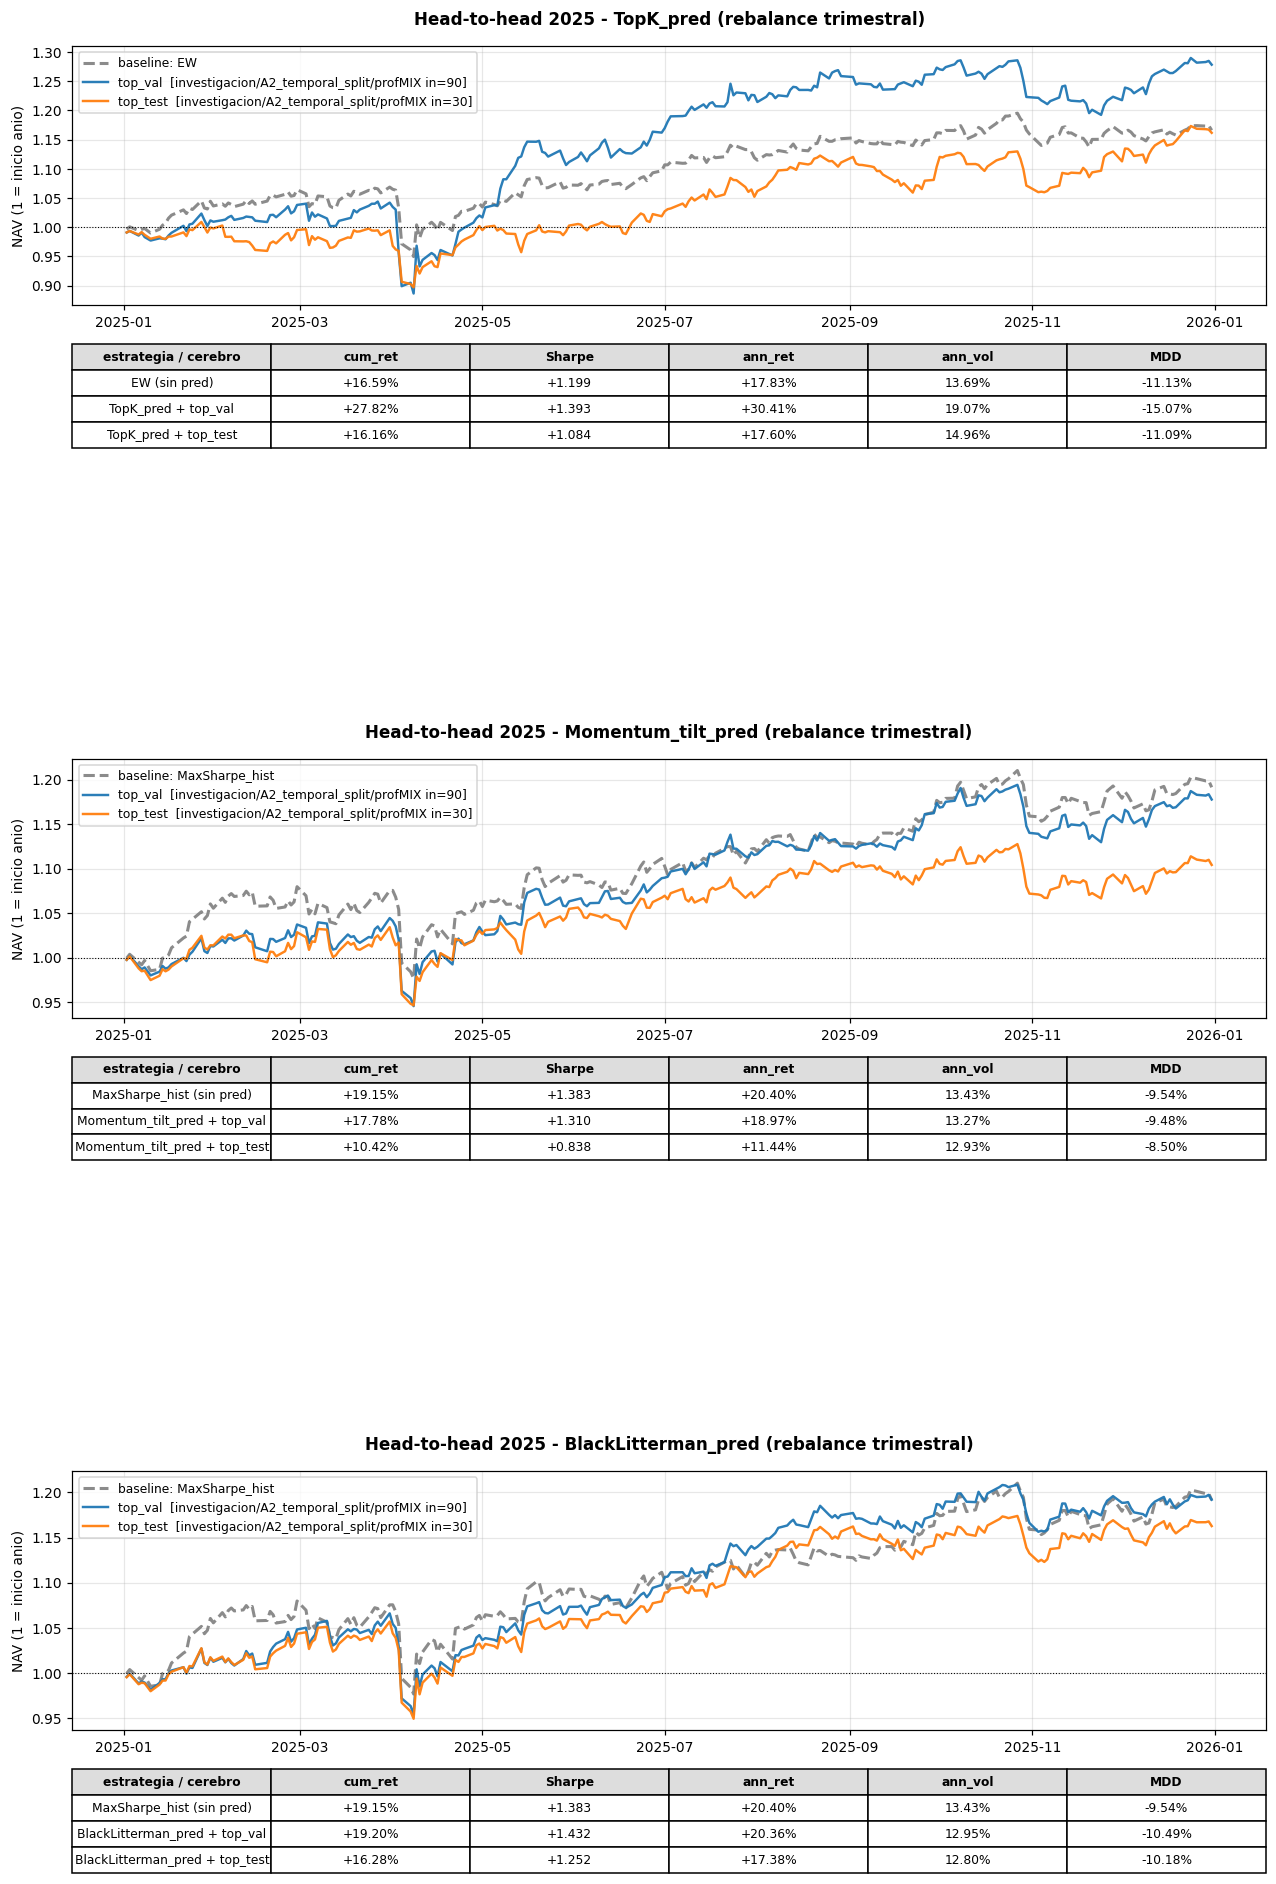

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\carteras_2025_head_to_head.png


In [15]:
BASELINE_FOR_STRAT = {
    "TopK_pred": "EW",
    "Momentum_tilt_pred": "MaxSharpe_hist",
    "BlackLitterman_pred": "MaxSharpe_hist",
}

MODEL_ORDER = ["top_val", "top_test", "ensemble"]
MODEL_COLORS = {
    "top_val":  "#1f77b4",
    "top_test": "#ff7f0e",
    "ensemble": "#2ca02c",
}
BASELINE_COLOR = "#7f7f7f"


def _find_run(strategy, pred_model):
    """Busca el backtest_run con esa estrategia y modelo de prediccion. Devuelve None si no existe."""
    for bt in backtest_runs:
        if bt["strategy"] == strategy and bt.get("pred_model", "none") == pred_model:
            return bt
        if bt["strategy"] == strategy:
            row = next((r for r in results_rows if r["strategy"] == strategy and r["pred_model"] == pred_model), None)
            if row is not None and bt["key"] == f"{strategy}_pred{pred_model}":
                return bt
    for bt in backtest_runs:
        if bt["key"] == f"{strategy}_pred{pred_model}":
            return bt
    return None


pred_strategies_in_data = [s for s in ["TopK_pred", "Momentum_tilt_pred", "BlackLitterman_pred"]
                           if any(r["strategy"] == s for r in results_rows)]

if pred_strategies_in_data:
    n_strats = len(pred_strategies_in_data)
    fig, axes = plt.subplots(n_strats, 1, figsize=(14, 5.8 * n_strats), squeeze=False)

    for i, strat in enumerate(pred_strategies_in_data):
        ax = axes[i, 0]
        baseline_name = BASELINE_FOR_STRAT.get(strat, "EW")
        baseline_bt = _find_run(baseline_name, "none")

        if baseline_bt is not None:
            ax.plot(baseline_bt["nav"].index, baseline_bt["nav"].values,
                    label=f"baseline: {baseline_name}", color=BASELINE_COLOR, linewidth=2.0, linestyle="--", alpha=0.9)

        table_rows = []
        if baseline_bt is not None:
            table_rows.append([
                f"{baseline_name} (sin pred)",
                f"{baseline_bt['cum_return']:+.2%}",
                f"{baseline_bt['sharpe']:+.3f}",
                f"{baseline_bt['ann_return']:+.2%}",
                f"{baseline_bt['ann_vol']:.2%}",
                f"{baseline_bt['max_drawdown']:+.2%}",
            ])

        for pred_label in MODEL_ORDER:
            bt = _find_run(strat, pred_label)
            if bt is None:
                continue
            meta = PRED_META.get(pred_label, {})
            leg = f"{pred_label}  [{meta.get('descripcion', '?')}]"
            ax.plot(bt["nav"].index, bt["nav"].values,
                    label=leg, color=MODEL_COLORS[pred_label], linewidth=1.6, alpha=0.95)
            table_rows.append([
                f"{strat} + {pred_label}",
                f"{bt['cum_return']:+.2%}",
                f"{bt['sharpe']:+.3f}",
                f"{bt['ann_return']:+.2%}",
                f"{bt['ann_vol']:.2%}",
                f"{bt['max_drawdown']:+.2%}",
            ])

        ax.axhline(1, color="black", linestyle=":", linewidth=0.7)
        ax.set_title(f"Head-to-head 2025 - {strat} (rebalance trimestral)", fontweight="bold", fontsize=11, pad=14)
        ax.set_ylabel("NAV (1 = inicio anio)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

        if table_rows:
            col_labels = ["estrategia / cerebro", "cum_ret", "Sharpe", "ann_ret", "ann_vol", "MDD"]
            tbl = ax.table(
                cellText=table_rows,
                colLabels=col_labels,
                loc="bottom",
                bbox=[0.0, -0.55, 1.0, 0.40],
                cellLoc="center",
            )
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(8)
            tbl.scale(1, 1.2)
            for k_col, _lab in enumerate(col_labels):
                tbl[0, k_col].set_facecolor("#dddddd")
                tbl[0, k_col].set_text_props(weight="bold")

    fig.subplots_adjust(hspace=1.75, top=0.96, bottom=0.08)
    fig.savefig(RESULTS_DIR / "carteras_2025_head_to_head.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'carteras_2025_head_to_head.png'}")
else:
    print("No hay estrategias con-pred en los resultados; revisar el loop principal.")

Tabla pivote - Sharpe (estrategia x modelo):
pred_model            none  top_val  top_test
strategy                                     
EW                   1.199      NaN       NaN
MinVar               1.075      NaN       NaN
MaxSharpe_hist       1.383      NaN       NaN
TopK_pred              NaN    1.393     1.084
Momentum_tilt_pred     NaN    1.310     0.838
BlackLitterman_pred    NaN    1.432     1.252

Tabla pivote - ann_return:
pred_model              none  top_val top_test
strategy                                      
EW                   +17.83%                  
MinVar               +15.24%                  
MaxSharpe_hist       +20.40%                  
TopK_pred                     +30.41%  +17.60%
Momentum_tilt_pred            +18.97%  +11.44%
BlackLitterman_pred           +20.36%  +17.38%

Tabla pivote - max_drawdown:
pred_model              none  top_val top_test
strategy                                      
EW                   -11.13%                  
MinVar      

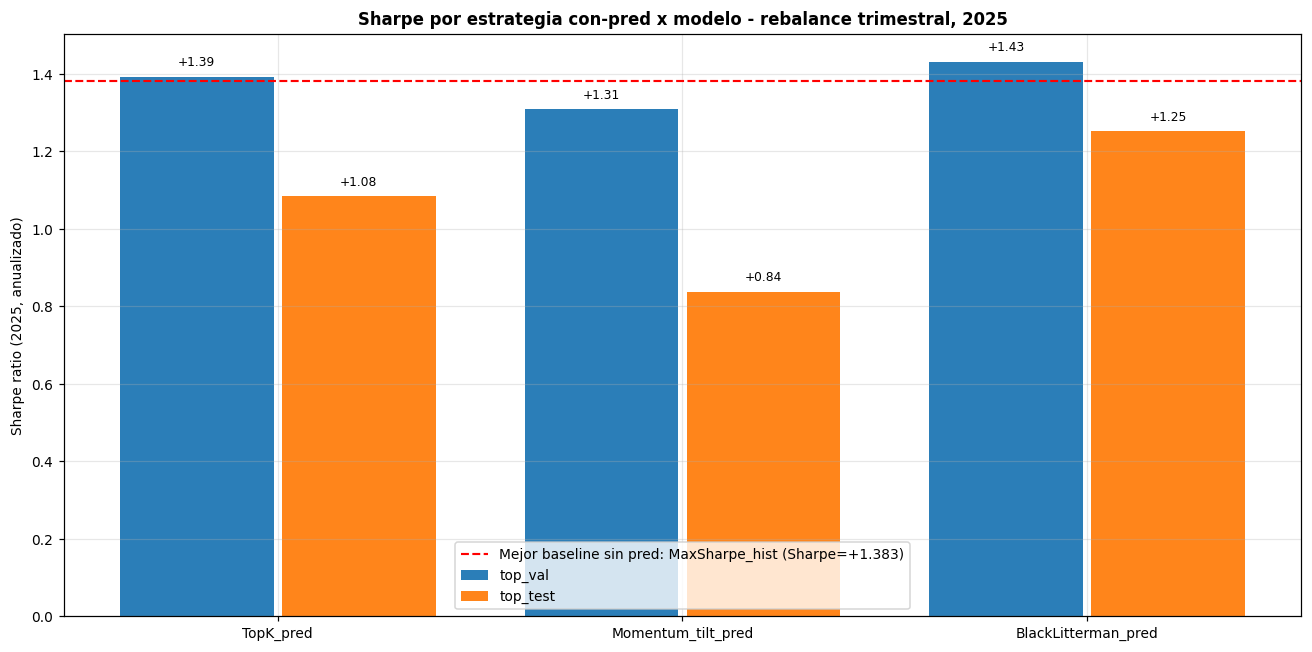

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\carteras_2025_sharpe_grouped.png


In [16]:
if len(df_results) > 0:
    strat_order_full = ["EW", "MinVar", "MaxSharpe_hist", "TopK_pred", "Momentum_tilt_pred", "BlackLitterman_pred"]
    strat_order = [s for s in strat_order_full if s in df_results["strategy"].unique()]
    col_order = ["none"] + [m for m in MODEL_ORDER if m in df_results["pred_model"].unique()]

    def _pivot(metric):
        pv = df_results.pivot_table(index="strategy", columns="pred_model", values=metric, aggfunc="first")
        pv = pv.reindex(index=strat_order, columns=col_order)
        return pv

    pivot_sharpe = _pivot("sharpe")
    pivot_annret = _pivot("ann_return")
    pivot_mdd = _pivot("max_drawdown")

    print("Tabla pivote - Sharpe (estrategia x modelo):")
    print(pivot_sharpe.round(3).to_string())
    def _fmt_pct(df):
        if hasattr(df, "map"):
            return df.map(lambda v: f"{v:+.2%}" if pd.notna(v) else "")
        return df.applymap(lambda v: f"{v:+.2%}" if pd.notna(v) else "")
    print("\nTabla pivote - ann_return:")
    print(_fmt_pct(pivot_annret).to_string())
    print("\nTabla pivote - max_drawdown:")
    print(_fmt_pct(pivot_mdd).to_string())

    pivot_sharpe.to_csv(RESULTS_DIR / "carteras_2025_pivot_sharpe.csv")
    pivot_annret.to_csv(RESULTS_DIR / "carteras_2025_pivot_annret.csv")
    pivot_mdd.to_csv(RESULTS_DIR / "carteras_2025_pivot_mdd.csv")
    print(f"\nGuardados pivots en {RESULTS_DIR}")

    pred_strat_order = [s for s in strat_order if STRATEGIES.get(s, {}).get("uses_pred", False)]
    baselines_only = df_results[df_results["pred_model"] == "none"]
    best_baseline_sharpe = float(baselines_only["sharpe"].max()) if len(baselines_only) > 0 else 0.0
    best_baseline_name = baselines_only.loc[baselines_only["sharpe"].idxmax(), "strategy"] if len(baselines_only) > 0 else "n/a"

    fig, ax = plt.subplots(figsize=(12, 6))
    n_strats = len(pred_strat_order)
    bar_models = [m for m in MODEL_ORDER if m in pivot_sharpe.columns]
    width = 0.8 / max(1, len(bar_models))
    x = np.arange(n_strats)

    for j, mdl in enumerate(bar_models):
        vals = [pivot_sharpe.loc[s, mdl] if (s in pivot_sharpe.index and mdl in pivot_sharpe.columns) else np.nan
                for s in pred_strat_order]
        positions = x + j * width - (len(bar_models) - 1) * width / 2
        bars = ax.bar(positions, vals, width=width * 0.95, color=MODEL_COLORS[mdl], label=mdl, alpha=0.95)
        for rect, v in zip(bars, vals):
            if pd.notna(v):
                ax.text(rect.get_x() + rect.get_width() / 2, v + (0.02 if v >= 0 else -0.05),
                        f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

    ax.axhline(best_baseline_sharpe, color="red", linestyle="--", linewidth=1.4,
               label=f"Mejor baseline sin pred: {best_baseline_name} (Sharpe={best_baseline_sharpe:+.3f})")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(pred_strat_order)
    ax.set_ylabel("Sharpe ratio (2025, anualizado)")
    ax.set_title("Sharpe por estrategia con-pred x modelo - rebalance trimestral, 2025", fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="best", fontsize=9)

    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "carteras_2025_sharpe_grouped.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'carteras_2025_sharpe_grouped.png'}")

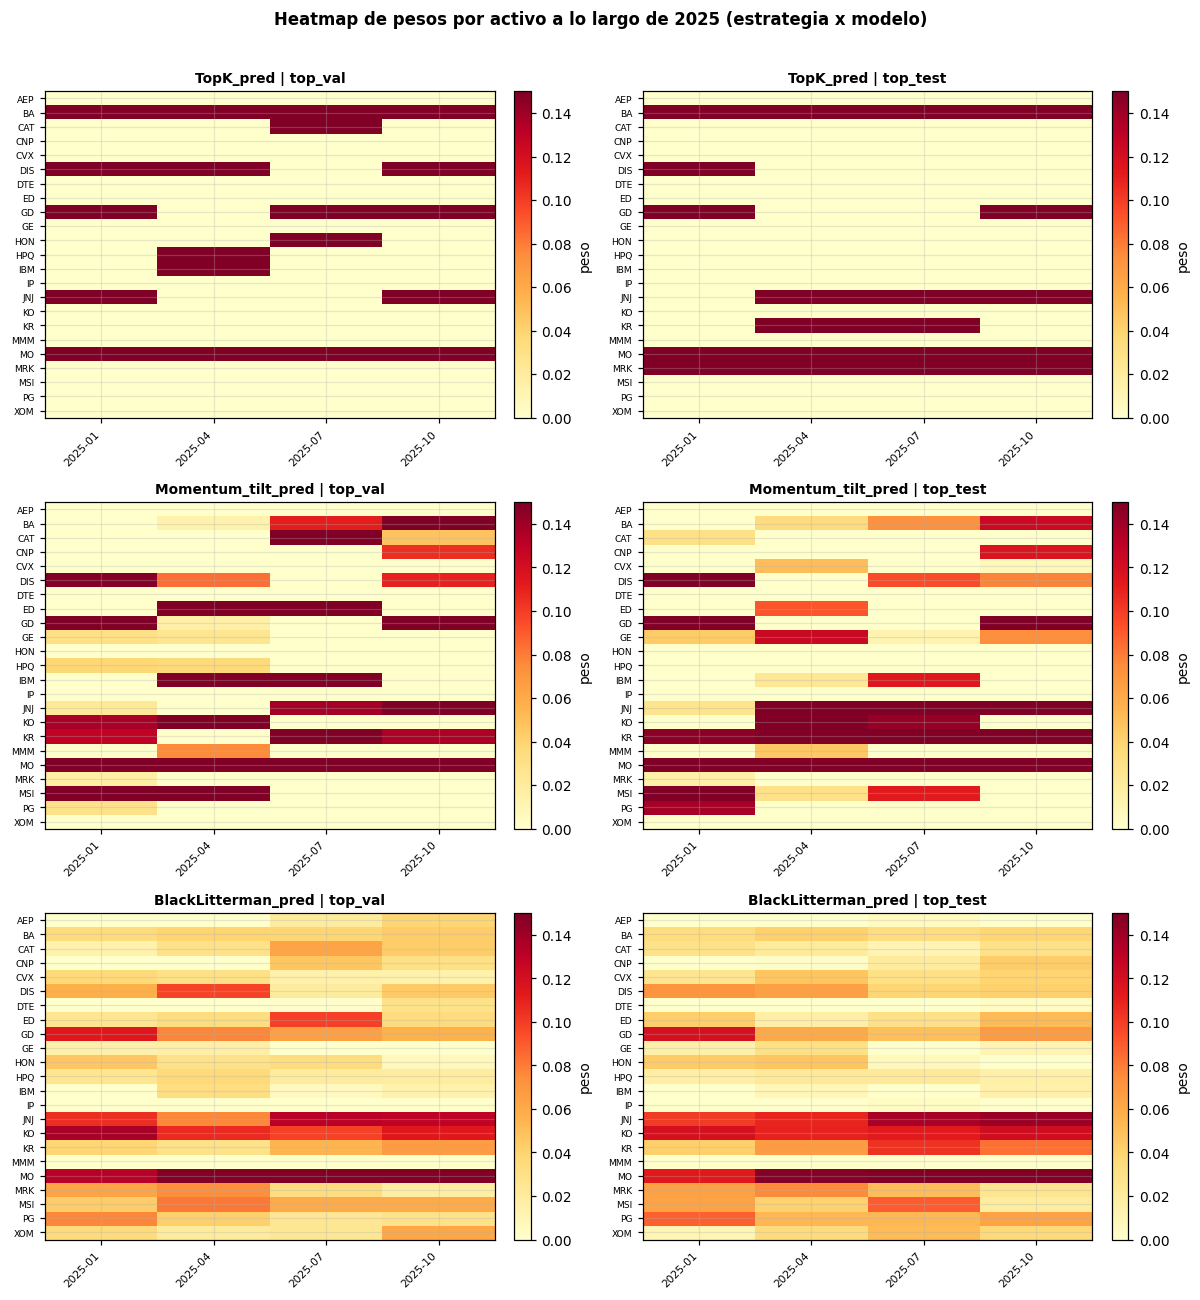

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\carteras_2025_pesos_heatmap.png


In [17]:
pred_strategies = [s for s in ["TopK_pred", "Momentum_tilt_pred", "BlackLitterman_pred"]
                   if any(r["strategy"] == s for r in results_rows)]

if pred_strategies:
    nrows = len(pred_strategies)
    ncols = len([m for m in MODEL_ORDER if m in PRED_MODELS])
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows), squeeze=False)

    for i, strat in enumerate(pred_strategies):
        for j, pred_label in enumerate([m for m in MODEL_ORDER if m in PRED_MODELS]):
            ax = axes[i, j]
            bt = _find_run(strat, pred_label)
            if bt is None or bt["weights_history"] is None or len(bt["weights_history"]) == 0:
                ax.axis("off")
                ax.set_title(f"{strat} | {pred_label}\n(sin datos)", fontsize=9)
                continue
            wh = bt["weights_history"]
            data = wh.fillna(0).values.T
            im = ax.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=MAX_WEIGHT)
            ax.set_xticks(range(len(wh)))
            ax.set_xticklabels([d.strftime("%Y-%m") for d in wh.index], rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(len(wh.columns)))
            ax.set_yticklabels(wh.columns, fontsize=6)
            ax.set_title(f"{strat} | {pred_label}", fontsize=9, fontweight="bold")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="peso")

    fig.suptitle("Heatmap de pesos por activo a lo largo de 2025 (estrategia x modelo)", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(RESULTS_DIR / "carteras_2025_pesos_heatmap.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'carteras_2025_pesos_heatmap.png'}")
else:
    print("No hay estrategias con-pred en results.")

## 7. Conclusiones

Generadas automáticamente desde los resultados. Aprovechables directamente para la presentación oral (sección "Carteras 2025").

In [18]:
conclusiones = []

if len(df_results) > 0:
    n_runs = len(df_results)
    conclusiones.append(
        f"Se ejecutaron {n_runs} backtests durante {YEAR_BACKTEST} (frecuencia trimestral unica)."
    )

    conclusiones.append(
        f"Modelos comparados: top_val={TOP_VAL_META['descripcion']} (mae_val={TOP_VAL_META['mae_val']:.6f}), "
        f"top_test={TOP_TEST_META['descripcion']} (mae_test={TOP_TEST_META['mae_test']:.6f}), ensemble deep-dive top-3."
    )

    by_sharpe = df_results.sort_values("sharpe", ascending=False)
    top1 = by_sharpe.iloc[0]
    conclusiones.append(
        f"Mejor Sharpe global: {top1['strategy']} + pred={top1['pred_model']} -> "
        f"Sharpe={top1['sharpe']:+.3f}, ann_ret={top1['ann_return']:+.2%}, MDD={top1['max_drawdown']:+.2%}."
    )

    sin_pred = df_results[df_results["pred_model"] == "none"]
    con_pred = df_results[df_results["pred_model"] != "none"]
    if len(sin_pred) > 0 and len(con_pred) > 0:
        sharpe_sin = float(sin_pred["sharpe"].max())
        sharpe_con = float(con_pred["sharpe"].max())
        delta = sharpe_con - sharpe_sin
        best_sin = sin_pred.loc[sin_pred["sharpe"].idxmax(), "strategy"]
        if delta > 0.05:
            conclusiones.append(
                f"Las carteras CON predicciones mejoran al mejor baseline sin pred ({best_sin}, Sharpe={sharpe_sin:+.3f}) en +{delta:.3f}."
            )
        elif delta < -0.05:
            conclusiones.append(
                f"Las predicciones NO superan al mejor baseline sin pred ({best_sin}, Sharpe={sharpe_sin:+.3f}); delta Sharpe = {delta:+.3f}."
            )
        else:
            conclusiones.append(
                f"Predicciones vs mejor baseline ({best_sin}): impacto en Sharpe casi neutro (delta = {delta:+.3f})."
            )

    pred_models_in_data = [p for p in MODEL_ORDER if p in df_results["pred_model"].values]
    if len(pred_models_in_data) >= 2:
        med_per_model = df_results[df_results["pred_model"].isin(pred_models_in_data)].groupby("pred_model")["sharpe"].mean()
        order_str = ", ".join([f"{m}={med_per_model[m]:+.3f}" for m in pred_models_in_data if m in med_per_model.index])
        best_model = med_per_model.idxmax()
        conclusiones.append(
            f"Sharpe medio por cerebro a lo largo de las 3 estrategias con-pred: {order_str}. "
            f"Cerebro mas consistente: {best_model}."
        )

        if "top_val" in med_per_model.index and "top_test" in med_per_model.index:
            d_vt = float(med_per_model["top_val"] - med_per_model["top_test"])
            if abs(d_vt) < 0.03:
                conclusiones.append(
                    f"top_val y top_test producen Sharpes equivalentes en cartera (|delta|={abs(d_vt):.3f}): el sobreajuste a test no compra alpha real."
                )
            elif d_vt > 0:
                conclusiones.append(
                    f"top_val supera a top_test en Sharpe medio (+{d_vt:.3f}): el criterio honesto (mae_val) gana en OOS."
                )
            else:
                conclusiones.append(
                    f"top_test supera a top_val en Sharpe medio (por +{abs(d_vt):.3f}): los retornos de 2025 alinean mejor con el modelo elegido por test (posible 'lucky test' en OOS de 2025)."
                )

        if "ensemble" in med_per_model.index:
            d_ens = med_per_model["ensemble"] - max(med_per_model.get("top_val", -np.inf), med_per_model.get("top_test", -np.inf))
            if d_ens > 0.03:
                conclusiones.append(f"El ensemble (Sharpe medio={med_per_model['ensemble']:+.3f}) supera al mejor individual.")
            elif d_ens < -0.03:
                conclusiones.append(f"El mejor individual supera al ensemble por {-d_ens:+.3f} en Sharpe medio: la diversificacion entre modelos no aporta aqui.")
            else:
                conclusiones.append(f"Ensemble vs mejor individual: empate en Sharpe medio (|delta|={abs(d_ens):.3f}).")

    ranking = by_sharpe[["strategy", "pred_model", "sharpe", "ann_return", "max_drawdown", "mean_turnover"]].reset_index(drop=True)
    print("Ranking carteras 2025 por Sharpe:")
    print(ranking.to_string(index=False))

print("\nConclusiones automaticas:")
print("=" * 80)
for i, c in enumerate(conclusiones, 1):
    print(f"{i:2d}. {c}")

Ranking carteras 2025 por Sharpe:
           strategy pred_model   sharpe  ann_return  max_drawdown  mean_turnover
BlackLitterman_pred    top_val 1.431910    0.203649     -0.104910       0.396942
          TopK_pred    top_val 1.392679    0.304058     -0.150743       0.600000
     MaxSharpe_hist       none 1.382681    0.203977     -0.095449       0.517523
 Momentum_tilt_pred    top_val 1.309599    0.189723     -0.094778       0.588157
BlackLitterman_pred   top_test 1.251625    0.173757     -0.101835       0.374680
                 EW       none 1.199385    0.178320     -0.111321       1.000000
          TopK_pred   top_test 1.084025    0.176014     -0.110869       0.400000
             MinVar       none 1.074542    0.152374     -0.109387       0.423552
 Momentum_tilt_pred   top_test 0.837897    0.114413     -0.084979       0.574134

Conclusiones automaticas:
 1. Se ejecutaron 9 backtests durante 2025 (frecuencia trimestral unica).
 2. Modelos comparados: top_val=investigacion/A2_tempor

### Reflexión cualitativa para la presentación

- **EW como referencia**: en mercados eficientes con activos correlacionados (23 grandes blue chips del SP500), la cartera equiponderada es **muy difícil de batir** sin información extra. Es el benchmark honesto.
- **MinVar y MaxSharpe histórico**: dependen de cuán estable sea el régimen de volatilidad/correlación 252 días antes vs durante 2025. Si hay un shift de régimen, fallan.
- **Top-K con predicciones**: depende crucialmente de la **calidad direccional** de las predicciones (no de la magnitud absoluta). Si el modelo acierta el orden relativo de los 23 activos, Top-K funciona.
- **Momentum tilt**: combina la `μ_hist` (estable) con la predicción (informativa). Más robusto que Top-K cuando las predicciones son ruidosas.
- **Black-Litterman**: el más "elegante" matemáticamente pero el más sensible a la calibración de `τ` y `Ω`. Tiende a quedarse cerca del prior (equilibrium).

### Por qué top_val vs top_test vs ensemble

- **`top_val`** es el modelo elegido por **mae de validación** — el criterio académicamente "puro": el split de test queda intocado y la selección no incurre en sobreajuste a test. Es lo que se reportaría en producción.
- **`top_test`** es el modelo con **mejor número absoluto sobre test**. Útil para mostrar el techo empírico de la familia, pero hereda sesgo de selección si lo usaras para decidir despliegue.
- **`ensemble`** (deep-dive top-3) reduce la varianza de un solo modelo: si el coste extra de inferencia (×3) está justificado, lo dirá la comparación de Sharpe.

Que los 3 se comparen sobre **las mismas 3 estrategias** (Top-K, Momentum tilt, BL) con la **misma frecuencia trimestral** convierte el experimento en un test casi-controlado: el único factor que cambia es el cerebro que predice `μ_pred`.



## Notas metodológicas — modelos fuera del comparativo

El **selector automático** del bloque 2 únicamente considera modelos que:

1. Aceptan input `(in_w, 23)` de **log-returns crudos** (lo que el pipeline actual sabe construir y normalizar).
2. Producen output `(23,)` que se interpreta como **retorno medio a 90 días** por activo.
3. Tienen `out_window = 90` (alineado con el horizonte del backtest trimestral).
4. Tienen el `.keras` físicamente guardado en `models/`.


**Implicaciones**:

- El selector trabaja sobre el universo `mixto_*` + `mixto_dd_*` + `inv_{A2_temporal_split, A4_dbscan_filter, C3_sample_weights}_*` con `out_window=90`.
- Esto sigue siendo un universo suficiente (≈ 80 modelos compatibles) para que el ranking por `mae_val` y por `mae_test` no esté sesgado.
- Ampliar a las técnicas excluidas se reduce a implementar, para cada una, la función `predict_returns_X(window)` con su pre-procesado correcto y registrarla en `PRED_MODELS` siguiendo el patrón del cheat sheet.

## 8. Validación final + cheat sheet

In [19]:
checks_total = 0
checks_ok = 0


def _do(label, cond, detail=""):
    global checks_total, checks_ok
    checks_total += 1
    icono = "[OK]" if cond else "[FAIL]"
    print(f"{icono} {label} {detail}")
    if cond:
        checks_ok += 1


print("Validacion del notebook 08")
print("=" * 80)

_do("CSV carteras_2025_resultados.csv existe", (RESULTS_DIR / "carteras_2025_resultados.csv").exists())
if (RESULTS_DIR / "carteras_2025_resultados.csv").exists():
    df_check = pd.read_csv(RESULTS_DIR / "carteras_2025_resultados.csv")
    _do("CSV con 12-13 filas (1 EW + 2 baselines Q + 3 estrategias x 3 modelos)", 12 <= len(df_check) <= 13,
        f"(actual: {len(df_check)})")
    cols_obligatorias = {"strategy", "freq", "pred_model", "sharpe", "ann_return", "ann_vol", "max_drawdown"}
    _do("CSV tiene columnas requeridas", cols_obligatorias.issubset(set(df_check.columns)),
        f"(faltan: {cols_obligatorias - set(df_check.columns)})")
    _do("Solo frecuencias Q o Y en los resultados (sin mensual)", set(df_check["freq"].unique()).issubset({"Q", "Y"}),
        f"(actual: {sorted(df_check['freq'].unique().tolist())})")
    _do("Pred models = {none, top_val, top_test, ensemble}", set(df_check["pred_model"].unique()).issubset({"none", "top_val", "top_test", "ensemble"}),
        f"(actual: {sorted(df_check['pred_model'].unique().tolist())})")

_do("CSV returns existe", (RESULTS_DIR / "carteras_2025_returns.csv").exists())
_do("CSV pesos existe", (RESULTS_DIR / "carteras_2025_pesos.csv").exists())
_do("CSV pivot Sharpe existe", (RESULTS_DIR / "carteras_2025_pivot_sharpe.csv").exists())

for fname in ["carteras_2025_head_to_head.png", "carteras_2025_sharpe_grouped.png", "carteras_2025_pesos_heatmap.png"]:
    _do(f"Figura {fname}", (RESULTS_DIR / fname).exists())

_do("Modelo TOP_VAL  cargable", model_top_val is not None,  f"({TOP_VAL_META['model_file']})")
_do("Modelo TOP_TEST cargable", model_top_test is not None, f"({TOP_TEST_META['model_file']})")
_do("Ensemble (3 modelos) cargable", len(ensemble_models) == 3, f"(actual: {len(ensemble_models)})")

if len(df_results) > 0:
    n_strats_distintas = df_results["strategy"].nunique()
    _do("6 estrategias presentes", n_strats_distintas == 6, f"(actual: {n_strats_distintas})")

print("=" * 80)
print(f"Resultado: {checks_ok}/{checks_total} checks superados.")

Validacion del notebook 08
[OK] CSV carteras_2025_resultados.csv existe 
[FAIL] CSV con 12-13 filas (1 EW + 2 baselines Q + 3 estrategias x 3 modelos) (actual: 9)
[OK] CSV tiene columnas requeridas (faltan: set())
[OK] Solo frecuencias Q o Y en los resultados (sin mensual) (actual: ['Q', 'Y'])
[OK] Pred models = {none, top_val, top_test, ensemble} (actual: ['none', 'top_test', 'top_val'])
[OK] CSV returns existe 
[OK] CSV pesos existe 
[OK] CSV pivot Sharpe existe 
[OK] Figura carteras_2025_head_to_head.png 
[OK] Figura carteras_2025_sharpe_grouped.png 
[OK] Figura carteras_2025_pesos_heatmap.png 
[OK] Modelo TOP_VAL  cargable (inv_A2_temporal_split_profMIX_in90_out90.keras)
[OK] Modelo TOP_TEST cargable (inv_A2_temporal_split_profMIX_in30_out90.keras)
[FAIL] Ensemble (3 modelos) cargable (actual: 0)
[OK] 6 estrategias presentes (actual: 6)
Resultado: 13/15 checks superados.


### Cheat sheet

**Forzar un modelo concreto en lugar del que elige el selector automático** (útil para experimentar):

```python
import types

custom_path = MODELS_DIR / "mixto_dd_convLSTM_causal_in90_out90.keras"
custom_model = load_model(custom_path, compile=False)
custom_in_w = int(custom_model.input_shape[1])

def predict_returns_custom(window):
    return _predict_single(custom_model, window, in_w=custom_in_w)

predict_returns_custom.input_window = custom_in_w
predict_returns_custom.descripcion = f"custom: {custom_path.name}"

PRED_MODELS["custom"] = predict_returns_custom
PRED_META["custom"] = {
    "label": "custom", "model_file": custom_path.name, "input_window": custom_in_w,
    "mae_val": None, "mae_test": None, "descripcion": predict_returns_custom.descripcion,
}
```

**Añadir un modelo de investigación compatible** (basta con que use entrada de log-returns 23 canales):

```python
inv_path = MODELS_DIR / "inv_C3_sample_weights_profMIX_in90_out90.keras"
m = load_model(inv_path, compile=False)

def predict_returns_inv(window):
    return _predict_single(m, window, in_w=int(m.input_shape[1]))

predict_returns_inv.input_window = int(m.input_shape[1])
predict_returns_inv.descripcion = inv_path.name
PRED_MODELS["inv_c3"] = predict_returns_inv
```

> Modelos con pre-procesado distinto (A1 PCA, B1 simple returns, B2 rolling-norm, B3/B4 canales extra, C1 fracdiff, C4 triple barrera) requieren código adicional de inferencia y por eso **no están en el selector automático**.

**Cambiar la frecuencia de rebalance** (mensual, por ejemplo):

```python
REBALANCE_FREQ = "M"
```

**Cambiar k en top-K**:

```python
TOP_K = 10
STRATEGIES["TopK10_pred"] = {"fn": lambda mu, cov, pred: weights_top_k(mu, cov, pred, k=10), "uses_pred": True, "rebalances": True}
```

**Re-ejecutar todo desde cero**: borrar `results/carteras_2025_*.csv` y ejecutar todas las celdas.